# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

# **Mount Google Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Load Dataset**

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Data Science Group Project/Dataset.csv")

print(df.head())
print(df.info())

                    Location No. of Foreign Tourists 2010  \
0    Colombo National Museum                       16,058   
1    National History Museum                          605   
2      Kandy National Museum                          951   
3  Ratnapura National Museum                          103   
4      Galle National Museum                        1,198   

  No. of Local Tourists 2010  Unnamed: 3  Unnamed: 4  Unnamed: 5  Unnamed: 6  \
0                    235,472         NaN         NaN         NaN         NaN   
1                     53,357         NaN         NaN         NaN         NaN   
2                     29,255         NaN         NaN         NaN         NaN   
3                     10,614         NaN         NaN         NaN         NaN   
4                     15,964         NaN         NaN         NaN         NaN   

   Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10  
0         NaN         NaN         NaN          NaN  
1         NaN         NaN         NaN         

# **Clean Column Names**

In [4]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(".", "")
)

# **Clean Numeric Values**

In [5]:
for col in df.columns:
    if "tourist" in col:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "")
            .str.replace("-", "0")
        )
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# **Reshape Data**

In [6]:
foreign_cols = [c for c in df.columns if "foreign" in c]
local_cols   = [c for c in df.columns if "local" in c]

foreign_long = df.melt(
    id_vars=["location"],
    value_vars=foreign_cols,
    var_name="year",
    value_name="foreign_tourists"
)

local_long = df.melt(
    id_vars=["location"],
    value_vars=local_cols,
    var_name="year",
    value_name="local_tourists"
)

foreign_long["year"] = foreign_long["year"].str.extract(r"(\d{4})").astype(int)
local_long["year"]   = local_long["year"].str.extract(r"(\d{4})").astype(int)

df_long = foreign_long.merge(
    local_long,
    on=["location", "year"],
    how="inner"
)

# **Feature Engineering**

In [7]:
df_long["tourism_demand"] = (
    df_long["foreign_tourists"] + df_long["local_tourists"]
)

# **District Mapping**

In [8]:
district_mapping = {
    # Colombo
    "colombo national museum": "Colombo",
    "independence memorial museum": "Colombo",
    "dutch museum": "Colombo",
    "dehiwala": "Colombo",
    "natural history museum": "Colombo",

    # Galle
    "galle national museum": "Galle",
    "galle maritime museum": "Galle",
    "galle": "Galle",
    "hikkaduwa": "Galle",

    # Kandy
    "kandy national museum": "Kandy",
    "peradeniya": "Kandy",
    "hakgala": "Kandy",
    "udawattakele conservation forest / kandy": "Kandy",

    # Anuradhapura
    "anuradhapura": "Anuradhapura",
    "abhayagiriya": "Anuradhapura",
    "jethawanaya": "Anuradhapura",
    "sigiriya": "Anuradhapura",

    # Hambantota
    "yala": "Hambantota",
    "bundala": "Hambantota",
    "udawalawa": "Hambantota",

    # Polonnaruwa
    "minneriya": "Polonnaruwa",
    "kaudulla": "Polonnaruwa",

    # Puttalam
    "wilpattu": "Puttalam",

    # Ampara
    "lahugala": "Ampara",
    "gal oya": "Ampara",

    # Nuwara Eliya
    "horton plains": "Nuwara Eliya"
}

df_long["location"] = df_long["location"].str.lower().str.strip()
df_long["district"] = df_long["location"].map(district_mapping)

# **Aggregate to District Level**

In [9]:
district_df = (
    df_long
    .dropna(subset=["district"])
    .groupby(["district", "year"], as_index=False)
    .agg({"tourism_demand": "sum"})
)

# **Exploratory Data Analysis (EDA)**

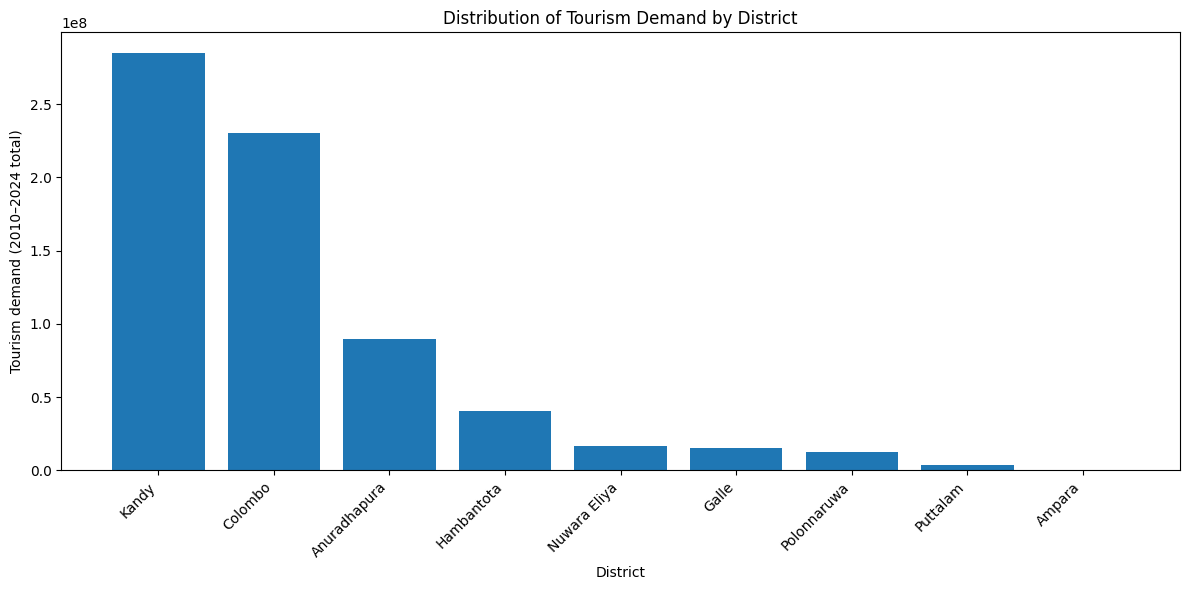

In [10]:
import matplotlib.pyplot as plt

# aggregate demand per district (all years)
dist_demand = (
    district_df
        .groupby("district", as_index=False)["tourism_demand"]
        .sum()
)

# sort for nicer plot
dist_demand = dist_demand.sort_values("tourism_demand", ascending=False)

plt.figure(figsize=(12,6))

plt.bar(
    dist_demand["district"],
    dist_demand["tourism_demand"]
)

plt.xlabel("District")
plt.ylabel("Tourism demand (2010–2024 total)")
plt.title("Distribution of Tourism Demand by District")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# **Features and Target**

In [11]:
features = ["year"]
target = "tourism_demand"

# **Linear Regression**

In [12]:
lr = LinearRegression()
lr.fit(district_df[features], district_df[target])

district_df["lr_prediction"] = lr.predict(district_df[features])

# **Geographically Weighted Regression (GWR)**

In [13]:
# ===============================
# 1. Prepare Coordinates for GWR
# ===============================
district_coords = {
    "Colombo": [6.9271, 79.8612],
    "Galle": [6.0535, 80.2210],
    "Kandy": [7.2906, 80.6337],
    "Anuradhapura": [8.3114, 80.4037],
    "Hambantota": [6.1240, 81.1218],
    "Polonnaruwa": [7.9406, 81.0000],
    "Puttalam": [8.0348, 79.8285],
    "Ampara": [7.2901, 81.6746],
    "Nuwara Eliya": [6.9497, 80.7894]
}

# Add lat/lon to district_df
district_df["lat"] = district_df["district"].map(lambda x: district_coords.get(x, [0,0])[0])
district_df["lon"] = district_df["district"].map(lambda x: district_coords.get(x, [0,0])[1])

# ===============================
# 2. Prepare X and y for GWR
# ===============================
# X = year (as a feature), y = tourism demand
X = district_df[["year"]].values
y = district_df["tourism_demand"].values.reshape(-1,1)
coords = district_df[["lat", "lon"]].values

# ===============================
# 3. Fit GWR Model (Fixed Bandwidth)
# ===============================
# With only 9 districts, we must fix the bandwidth manually
bandwidth = 3  # number of neighbors (cannot exceed number of districts)
gwr_model = GWR(coords, y, X, bw=bandwidth, fixed=True)
gwr_results = gwr_model.fit()

# ===============================
# 4. Model Evaluation (Accuracy)
# ===============================
print("Global R²:", gwr_results.R2)
print("Adjusted R²:", gwr_results.adj_R2)
print("AIC:", gwr_results.aic)
print("AICc:", gwr_results.aicc)

Global R²: 0.03421681722114589
Adjusted R²: -0.19112314745233916
AIC: 361.9184331992477
AICc: 365.1375684147407
